In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

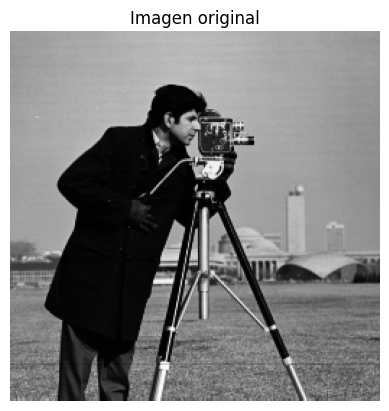

In [2]:
# Cargar imagen y convertir a escala de grises
img = Image.open("gr.png").convert("L")
img_array = np.array(img)

plt.imshow(img_array, cmap='gray')
plt.title("Imagen original")
plt.axis("off")
plt.show()

In [3]:
# Se realiza la convolución de forma manual

def conv2d(image, kernel, stride=1, padding=0):
    # Padding
    if padding > 0:
        image = np.pad(image, ((padding, padding), (padding, padding)), mode='constant')

    kernel_height, kernel_width = kernel.shape
    img_height, img_width = image.shape

    # Dimensiones de salida
    out_height = (img_height - kernel_height) // stride + 1
    out_width = (img_width - kernel_width) // stride + 1

    output = np.zeros((out_height, out_width))

    # Convolución manual
    for y in range(0, out_height):
        for x in range(0, out_width):
            region = image[y*stride:y*stride+kernel_height, x*stride:x*stride+kernel_width]
            output[y, x] = np.sum(region * kernel)

    return output


In [4]:
# Aplicación sobre una imagen
kernel = np.array([[ -1, -1, -1],
                   [ -1,  8, -1],
                   [ -1, -1, -1]])

# Sin padding, stride=1
result1 = conv2d(img_array, kernel, stride=1, padding=0)

# Con padding=1, stride=1
result2 = conv2d(img_array, kernel, stride=1, padding=1)

# Con stride=2
result3 = conv2d(img_array, kernel, stride=2, padding=0)


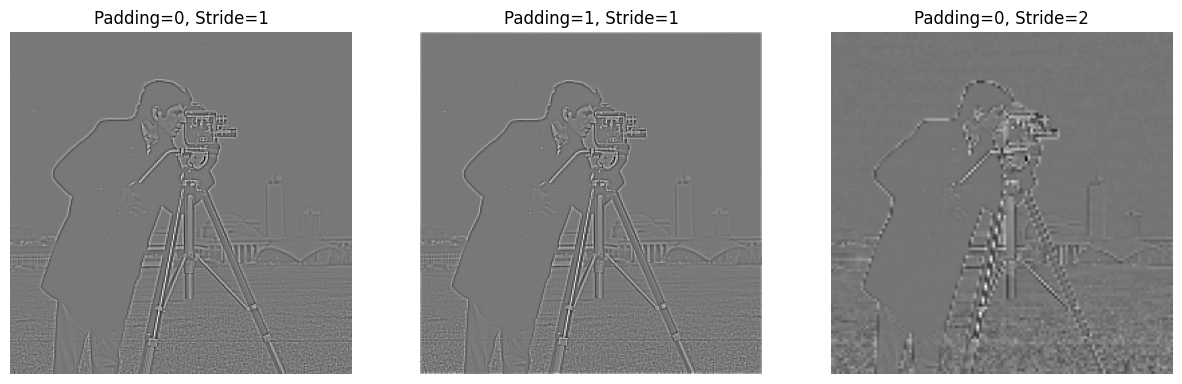

In [5]:
# Visualización de resultados
fig, axs = plt.subplots(1, 3, figsize=(15,5))

axs[0].imshow(result1, cmap='gray')
axs[0].set_title("Padding=0, Stride=1")

axs[1].imshow(result2, cmap='gray')
axs[1].set_title("Padding=1, Stride=1")

axs[2].imshow(result3, cmap='gray')
axs[2].set_title("Padding=0, Stride=2")

for ax in axs:
    ax.axis("off")
plt.show()
